In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.models.regression import (
    benchmark_regression,
    get_best_regression_models,
    add_regression_combined_score,
)
from src.models.classification import (
    benchmark_classification,
    get_best_classification_models,
    add_classification_combined_score,
    get_classification_models,
)
from src.utils.config import PROCESSED_DATA_DIR, TABLES_DIR, FIGURES_DIR

pd.set_option("display.max_columns", 200)

TABLES_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

In [3]:
positions = ["qb", "rb", "wr", "te", "dl", "lb", "db", "ol"] # positions we're looking at

# dictionary for datasets
reg_datasets = {}
q_datasets = {}
bin_datasets = {}

for pos in positions:
    reg_datasets[pos.upper()] = pd.read_csv(PROCESSED_DATA_DIR / f"{pos}_regression_data.csv")
    q_datasets[pos.upper()] = pd.read_csv(PROCESSED_DATA_DIR / f"{pos}_quantile_data.csv")
    bin_datasets[pos.upper()] = pd.read_csv(PROCESSED_DATA_DIR / f"{pos}_binary_data.csv")

print("Loaded regression datasets:")
for pos, df_pos in reg_datasets.items():
    print(pos, df_pos.shape)

print("\nLoaded quantile datasets:")
for pos, df_pos in q_datasets.items():
    print(pos, df_pos.shape)

print("\nLoaded binary datasets:")
for pos, df_pos in bin_datasets.items():
    print(pos, df_pos.shape)

Loaded regression datasets:
QB (211, 20)
RB (403, 19)
WR (647, 16)
TE (280, 16)
DL (802, 14)
LB (574, 15)
DB (897, 14)
OL (683, 11)

Loaded quantile datasets:
QB (211, 20)
RB (403, 19)
WR (647, 16)
TE (280, 16)
DL (802, 14)
LB (574, 15)
DB (897, 14)
OL (683, 11)

Loaded binary datasets:
QB (211, 20)
RB (403, 19)
WR (647, 16)
TE (280, 16)
DL (802, 14)
LB (574, 15)
DB (897, 14)
OL (683, 11)


In [4]:
# Regression benchmark
results_reg = benchmark_regression(reg_datasets)
results_reg.head()

,position,model,rmse,mae,r2
0,QB,Linear,19.962352,16.366409,0.033208
1,QB,Ridge,19.874505,16.320860,0.041698
2,QB,RF,17.047866,13.710137,0.294901
3,QB,ExtraTrees,20.218745,16.788750,0.008213
4,QB,GB,19.050969,14.650211,0.119470


In [5]:
print("=== REGRESSION RESULTS ===")
display(results_reg.sort_values(["position", "rmse"]))

=== REGRESSION RESULTS ===


,position,model,rmse,mae,r2
55,DB,SVR,8.621390,6.681314,-0.002204
49,DB,Ridge,8.797564,7.439599,-0.043582
48,DB,Linear,8.832271,7.478487,-0.051832
50,DB,RF,9.162791,7.655125,-0.132028
53,DB,HistGB,9.739471,7.922855,-0.279005
...,...,...,...,...,...
19,WR,ExtraTrees,13.723768,10.592460,-0.049763
22,WR,KNN,14.047701,10.589840,-0.099904
23,WR,SVR,14.082654,8.972942,-0.105385
21,WR,HistGB,14.437766,10.557824,-0.161835


In [6]:
best_reg_rmse = get_best_regression_models(results_reg, by="rmse")
print("=== BEST REGRESSION MODELS (by RMSE) ===")
display(best_reg_rmse[["position", "model", "rmse", "mae", "r2"]])

=== BEST REGRESSION MODELS (by RMSE) ===


,position,model,rmse,mae,r2
0,DB,SVR,8.621390,6.681314,-0.002204
1,DL,SVR,8.547665,7.038273,-0.102731
2,LB,SVR,10.232549,7.451565,-0.017047
3,OL,SVR,9.601728,8.241589,-0.077662
4,QB,RF,17.047866,13.710137,0.294901
5,RB,SVR,11.873728,9.016037,-0.041186
6,TE,SVR,7.034330,5.265255,0.030003
7,WR,Ridge,12.871412,10.254101,0.076585


In [7]:
results_reg_scored = add_regression_combined_score(results_reg)

best_reg_combined = (
    results_reg_scored.sort_values(by="score", ascending=True)
    .groupby("position")
    .first()
    .reset_index()
)

print("=== BEST REGRESSION MODELS (combined score) ===")
display(best_reg_combined[["position", "model", "rmse", "mae", "r2", "score"]])

=== BEST REGRESSION MODELS (combined score) ===


,position,model,rmse,mae,r2,score
0,DB,SVR,8.621390,6.681314,-0.002204,6.337129
1,DL,SVR,8.547665,7.038273,-0.102731,7.412626
2,LB,SVR,10.232549,7.451565,-0.017047,7.522216
3,OL,SVR,9.601728,8.241589,-0.077662,8.049960
4,QB,RF,17.047866,13.710137,0.294901,9.687962
5,RB,SVR,11.873728,9.016037,-0.041186,9.053534
6,TE,SVR,7.034330,5.265255,0.030003,4.796707
7,WR,Ridge,12.871412,10.254101,0.076585,8.746082


In [8]:
# Save regression outputs
results_reg.to_csv(TABLES_DIR / "regression_results.csv", index=False)
best_reg_rmse.to_csv(TABLES_DIR / "regression_best_rmse.csv", index=False)
best_reg_combined.to_csv(TABLES_DIR / "regression_best_combined.csv", index=False)

print("Saved regression tables.")

Saved regression tables.


In [9]:
# Quantile multiclass benchmark
results_q = benchmark_classification(
    q_datasets,
    label_col="av_class_q",
    positive_class=2,
    include_advanced=True,
)

results_q.head()

c:\Users\solom\anaconda3\envs\PIC_16B_Project\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\solom\anaconda3\envs\PIC_16B_Project\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/st

,position,model,accuracy,f1_macro,f1_weighted,precision_macro,recall_macro,recall_star
0,QB,Logistic,0.433333,0.383598,0.398677,0.402836,0.412323,0.473684
1,QB,RF,0.400000,0.324242,0.339545,0.282083,0.381388,0.578947
2,QB,ExtraTrees,0.466667,0.413781,0.425776,0.477602,0.447411,0.578947
3,QB,GB,0.433333,0.392689,0.402487,0.401690,0.418425,0.578947
4,QB,HistGB,0.366667,0.312121,0.325606,0.283730,0.349352,0.526316


In [10]:
print("=== QUANTILE CLASSIFICATION RESULTS ===")
display(results_q.sort_values(["position", "f1_macro"], ascending=[True, False]))

=== QUANTILE CLASSIFICATION RESULTS ===


,position,model,accuracy,f1_macro,f1_weighted,precision_macro,recall_macro,recall_star
69,DB,CatBoost,0.400000,0.396061,0.395948,0.393122,0.406893,0.500000
60,DB,Logistic,0.400000,0.392706,0.394314,0.407483,0.415044,0.576923
63,DB,GB,0.395122,0.391044,0.401690,0.398901,0.392094,0.384615
61,DB,RF,0.370732,0.369953,0.374417,0.375885,0.374565,0.423077
64,DB,HistGB,0.370732,0.366393,0.370969,0.365282,0.369460,0.384615
...,...,...,...,...,...,...,...,...
24,WR,HistGB,0.390374,0.364047,0.383549,0.360821,0.370376,0.354167
29,WR,CatBoost,0.385027,0.362324,0.376999,0.361087,0.367493,0.354167
28,WR,XGBoost,0.374332,0.358833,0.370373,0.357243,0.368618,0.437500
25,WR,KNN,0.390374,0.327122,0.352954,0.344777,0.347293,0.208333


In [11]:
best_q_f1 = get_best_classification_models(results_q, by="f1_macro")
print("=== BEST QUANTILE MODELS (F1 macro) ===")
display(best_q_f1[["position", "model", "accuracy", "f1_macro", "recall_star"]])

=== BEST QUANTILE MODELS (F1 macro) ===


,position,model,accuracy,f1_macro,recall_star
0,DB,CatBoost,0.400000,0.396061,0.500000
1,DL,CatBoost,0.395604,0.388986,0.695652
2,LB,XGBoost,0.346154,0.344294,0.464286
3,OL,ExtraTrees,0.408759,0.404421,0.714286
4,QB,ExtraTrees,0.466667,0.413781,0.578947
5,RB,RF,0.398305,0.397187,0.481481
6,TE,Logistic,0.385542,0.373840,0.555556
7,WR,Logistic,0.475936,0.469862,0.395833


In [12]:
best_q_star = get_best_classification_models(results_q, by="recall_star")
print("=== BEST QUANTILE MODELS (star recall) ===")
display(best_q_star[["position", "model", "accuracy", "f1_macro", "recall_star"]])

=== BEST QUANTILE MODELS (star recall) ===


,position,model,accuracy,f1_macro,recall_star
0,DB,Logistic,0.400000,0.392706,0.576923
1,DL,ExtraTrees,0.357143,0.352691,0.695652
2,LB,ExtraTrees,0.307692,0.305966,0.571429
3,OL,ExtraTrees,0.408759,0.404421,0.714286
4,QB,NaiveBayes,0.266667,0.142222,0.842105
5,RB,SVC,0.262712,0.210606,0.592593
6,TE,SVC,0.325301,0.267569,0.777778
7,WR,XGBoost,0.374332,0.358833,0.437500


In [13]:
# combined performance score to evaluate classification models
results_q_scored = add_classification_combined_score(results_q)

# selecting best model per position by combined score
best_q_combined = (
    results_q_scored.sort_values(by="score", ascending=False)
    .groupby("position")
    .first()
    .reset_index()
)

print("=== BEST QUANTILE MODELS (combined score) ===")
display(best_q_combined[["position", "model", "accuracy", "f1_macro", "recall_star", "score"]])

=== BEST QUANTILE MODELS (combined score) ===


,position,model,accuracy,f1_macro,recall_star,score
0,DB,Logistic,0.400000,0.392706,0.576923,0.449430
1,DL,CatBoost,0.395604,0.388986,0.695652,0.482309
2,LB,RF,0.330769,0.334650,0.535714,0.394193
3,OL,ExtraTrees,0.408759,0.404421,0.714286,0.498248
4,QB,ExtraTrees,0.466667,0.413781,0.578947,0.473908
5,RB,Logistic,0.406780,0.396115,0.555556,0.446080
6,TE,RF,0.337349,0.297909,0.722222,0.433091
7,WR,Logistic,0.475936,0.469862,0.395833,0.448868


In [14]:
# Save quantile outputs
results_q.to_csv(TABLES_DIR / "quantile_results.csv", index=False)
best_q_f1.to_csv(TABLES_DIR / "quantile_best_f1.csv", index=False)
best_q_star.to_csv(TABLES_DIR / "quantile_best_star.csv", index=False)
best_q_combined.to_csv(TABLES_DIR / "quantile_best_combined.csv", index=False)

print("Saved quantile tables.")

Saved quantile tables.


In [15]:
# Binary benchmark
results_bin = benchmark_classification(
    bin_datasets,
    label_col="star",
    positive_class=1,
    include_advanced=True,
)

results_bin.head()

c:\Users\solom\anaconda3\envs\PIC_16B_Project\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
c:\Users\solom\anaconda3\envs\PIC_16B_Project\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/st

,position,model,accuracy,f1_macro,f1_weighted,precision_macro,recall_macro,recall_star
0,QB,Logistic,0.600000,0.588571,0.616000,0.613839,0.634921,0.722222
1,QB,RF,0.750000,0.673795,0.736861,0.701309,0.662698,0.444444
2,QB,ExtraTrees,0.716667,0.593787,0.683154,0.650327,0.591270,0.277778
3,QB,GB,0.750000,0.715100,0.754986,0.708791,0.726190,0.666667
4,QB,HistGB,0.733333,0.627329,0.706832,0.680000,0.619048,0.333333


In [16]:
print("=== BINARY CLASSIFICATION RESULTS ===")
display(results_bin.sort_values(["position", "f1_macro"], ascending=[True, False]))

=== BINARY CLASSIFICATION RESULTS ===


,position,model,accuracy,f1_macro,f1_weighted,precision_macro,recall_macro,recall_star
67,DB,SVC,0.629268,0.552299,0.643757,0.552276,0.561212,0.423077
69,DB,CatBoost,0.702439,0.547330,0.677880,0.565539,0.546757,0.230769
60,DB,Logistic,0.570732,0.546916,0.598095,0.579236,0.604512,0.673077
63,DB,GB,0.692683,0.540408,0.670745,0.553782,0.540221,0.230769
64,DB,HistGB,0.678049,0.537531,0.663127,0.544318,0.536765,0.250000
...,...,...,...,...,...,...,...,...
23,WR,GB,0.700535,0.546431,0.675086,0.565499,0.546238,0.229167
29,WR,CatBoost,0.700535,0.546431,0.675086,0.565499,0.546238,0.229167
22,WR,ExtraTrees,0.737968,0.543789,0.688627,0.617647,0.550959,0.166667
24,WR,HistGB,0.679144,0.514033,0.651878,0.525796,0.518210,0.187500


In [17]:
best_bin_f1 = get_best_classification_models(results_bin, by="f1_macro")
print("=== BINARY BEST MODELS (F1 macro) ===")
display(best_bin_f1[["position", "model", "accuracy", "f1_macro", "recall_star"]])

=== BINARY BEST MODELS (F1 macro) ===


,position,model,accuracy,f1_macro,recall_star
0,DB,SVC,0.629268,0.552299,0.423077
1,DL,NaiveBayes,0.780220,0.620833,0.521739
2,LB,GB,0.723077,0.579288,0.346154
3,OL,ExtraTrees,0.715328,0.588779,0.550000
4,QB,GB,0.750000,0.715100,0.666667
5,RB,ExtraTrees,0.762712,0.594502,0.280000
6,TE,SVC,0.759036,0.645299,0.500000
7,WR,Logistic,0.657754,0.596221,0.520833


In [18]:
best_bin_star = get_best_classification_models(results_bin, by="recall_star")
print("=== BINARY BEST MODELS (star recall) ===")
display(best_bin_star[["position", "model", "accuracy", "f1_macro", "recall_star"]])

=== BINARY BEST MODELS (star recall) ===


,position,model,accuracy,f1_macro,recall_star
0,DB,NaiveBayes,0.248780,0.199219,0.980769
1,DL,Logistic,0.604396,0.520842,0.739130
2,LB,Logistic,0.461538,0.422002,0.500000
3,OL,SVC,0.145985,0.127389,1.000000
4,QB,NaiveBayes,0.266667,0.224442,0.833333
5,RB,Logistic,0.516949,0.490261,0.680000
6,TE,NaiveBayes,0.650602,0.569641,0.562500
7,WR,Logistic,0.657754,0.596221,0.520833


In [19]:
# same idea as above

results_bin_scored = add_classification_combined_score(results_bin)

best_bin_combined = (
    results_bin_scored.sort_values(by="score", ascending=False)
    .groupby("position")
    .first()
    .reset_index()
)

print("=== BINARY BEST MODELS (combined score) ===")
display(best_bin_combined[["position", "model", "accuracy", "f1_macro", "recall_star", "score"]])

=== BINARY BEST MODELS (combined score) ===


,position,model,accuracy,f1_macro,recall_star,score
0,DB,Logistic,0.570732,0.546916,0.673077,0.589527
1,DL,NaiveBayes,0.780220,0.620833,0.521739,0.622982
2,LB,NaiveBayes,0.646154,0.558215,0.500000,0.558338
3,OL,ExtraTrees,0.715328,0.588779,0.550000,0.602455
4,QB,GB,0.750000,0.715100,0.666667,0.707550
5,RB,Logistic,0.516949,0.490261,0.680000,0.552521
6,TE,SVC,0.759036,0.645299,0.500000,0.624457
7,WR,Logistic,0.657754,0.596221,0.520833,0.585911


In [20]:
# Save binary outputs
results_bin.to_csv(TABLES_DIR / "binary_results.csv", index=False)
best_bin_f1.to_csv(TABLES_DIR / "binary_best_f1.csv", index=False)
best_bin_star.to_csv(TABLES_DIR / "binary_best_star.csv", index=False)
best_bin_combined.to_csv(TABLES_DIR / "binary_best_combined.csv", index=False)

print("Saved binary tables.")

Saved binary tables.


In [21]:
# Summary tables for report
print("=== FINAL REGRESSION SUMMARY ===")
display(best_reg_combined[["position", "model", "rmse", "mae", "r2"]])

print("=== FINAL QUANTILE SUMMARY ===")
display(best_q_combined[["position", "model", "accuracy", "f1_macro", "recall_star"]])

print("=== FINAL BINARY SUMMARY ===")
display(best_bin_combined[["position", "model", "accuracy", "f1_macro", "recall_star"]])

=== FINAL REGRESSION SUMMARY ===


,position,model,rmse,mae,r2
0,DB,SVR,8.621390,6.681314,-0.002204
1,DL,SVR,8.547665,7.038273,-0.102731
2,LB,SVR,10.232549,7.451565,-0.017047
3,OL,SVR,9.601728,8.241589,-0.077662
4,QB,RF,17.047866,13.710137,0.294901
5,RB,SVR,11.873728,9.016037,-0.041186
6,TE,SVR,7.034330,5.265255,0.030003
7,WR,Ridge,12.871412,10.254101,0.076585


=== FINAL QUANTILE SUMMARY ===


,position,model,accuracy,f1_macro,recall_star
0,DB,Logistic,0.400000,0.392706,0.576923
1,DL,CatBoost,0.395604,0.388986,0.695652
2,LB,RF,0.330769,0.334650,0.535714
3,OL,ExtraTrees,0.408759,0.404421,0.714286
4,QB,ExtraTrees,0.466667,0.413781,0.578947
5,RB,Logistic,0.406780,0.396115,0.555556
6,TE,RF,0.337349,0.297909,0.722222
7,WR,Logistic,0.475936,0.469862,0.395833


=== FINAL BINARY SUMMARY ===


,position,model,accuracy,f1_macro,recall_star
0,DB,Logistic,0.570732,0.546916,0.673077
1,DL,NaiveBayes,0.780220,0.620833,0.521739
2,LB,NaiveBayes,0.646154,0.558215,0.500000
3,OL,ExtraTrees,0.715328,0.588779,0.550000
4,QB,GB,0.750000,0.715100,0.666667
5,RB,Logistic,0.516949,0.490261,0.680000
6,TE,SVC,0.759036,0.645299,0.500000
7,WR,Logistic,0.657754,0.596221,0.520833


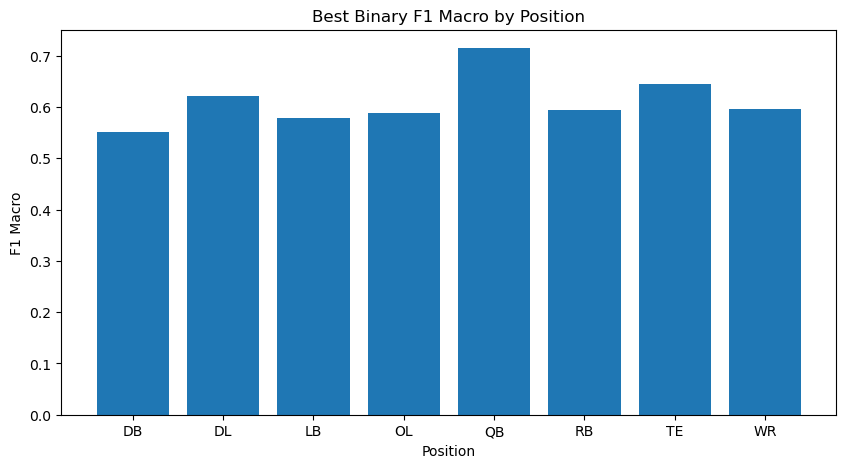

In [ ]:
# Bar chart of binary F1 scores by position
plt.figure(figsize=(10, 5))
plt.bar(best_bin_f1["position"], best_bin_f1["f1_macro"])
plt.title("Best Binary F1 Macro by Position")
plt.xlabel("Position")
plt.ylabel("F1 Macro")
plt.show()

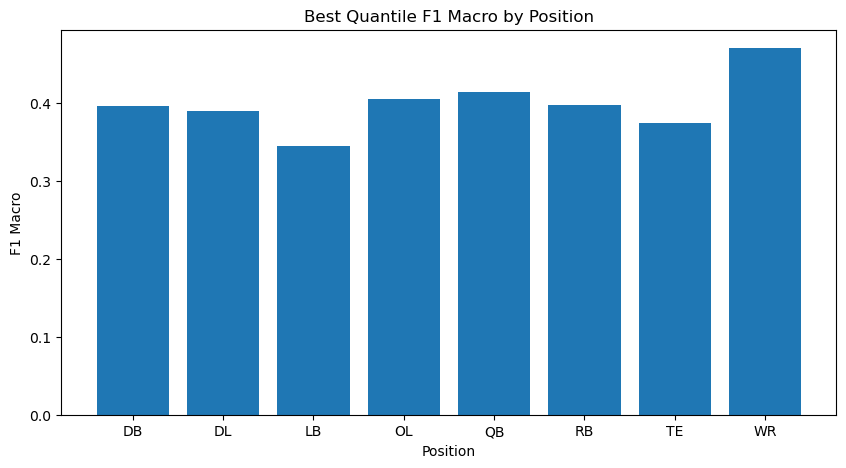

In [23]:
# Bar chart of quantile F1 scores by position
plt.figure(figsize=(10, 5))
plt.bar(best_q_f1["position"], best_q_f1["f1_macro"])
plt.title("Best Quantile F1 Macro by Position")
plt.xlabel("Position")
plt.ylabel("F1 Macro")
plt.show()

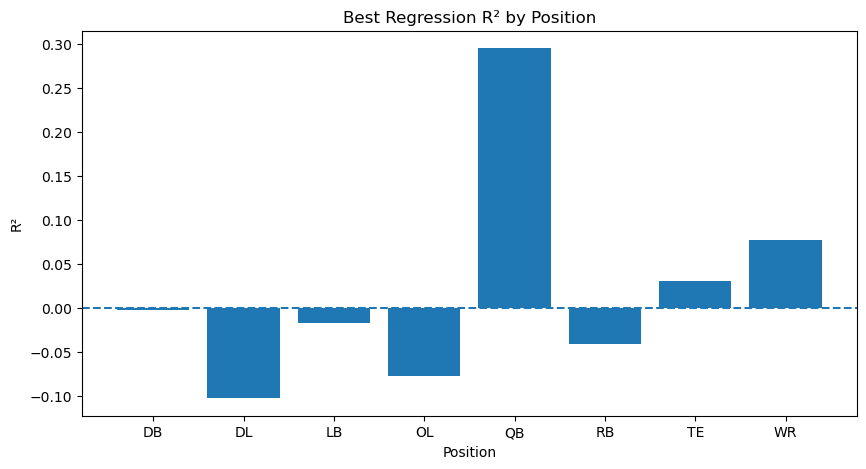

In [24]:
# Bar chart of regression R^2 by position
plt.figure(figsize=(10, 5))
plt.bar(best_reg_rmse["position"], best_reg_rmse["r2"])
plt.title("Best Regression R² by Position")
plt.xlabel("Position")
plt.ylabel("R²")
plt.axhline(0, linestyle="--")
plt.show()